# MeteoNet Radar Nowcasting: Exploratory Data Analysis

This notebook conducts an exploratory data analysis (EDA) of the raw Météo-France MeteoNet radar dataset prior to any preprocessing operations. 

In spatiotemporal precipitation nowcasting, raw sensor anomalies and severe power-law distributions can heavily destabilize machine learning optimization layers. To transition successfully from a general regression task to a robust weather intelligence pipeline, the dataset's structural, statistical, and temporal traits are mapped out comprehensively.

### Core Exploration Objectives:
1. **Dataset Schema Architecture**: Inspect the file organization, array data types, and internal geometric properties.
2. **Sparsity & Scaling Boundaries**: Analyze the severe power-law skew of rainfall intensities to inform data scaling and ceiling choices.
3. **Sensor Gaps & Missing Value Diagnostics**: Map spatial missing values (`-1` flags) and their geographic probability distributions across the domain grid.
4. **Temporal Continuity Validation**: Investigate delta-time intervals and domain intensity shifts between consecutive sweeps to establish sequence generation boundaries.

These foundational findings provide the direct scientific and algorithmic motivation for preprocessing pipeline choices.


In [1]:
from pathlib import Path
import warnings
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Standardize plotting templates
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "turbo"


In [2]:
# Root directory paths matching repository specifications
RAW_DIR = Path("../data/raw/NW_rainfall_2016/rainfall-NW-2016-01")

# Extract recursively tracked binary archive paths
archives = sorted(RAW_DIR.rglob("*.npz"))
print(f"Total structured NumPy compressed archives detected: {len(archives)}\n")

print("Sample Inventory Catalog Headers:")
print("-" * 50)
for f in archives[:10]:
    print(f" -> {f.name}")


Total structured NumPy compressed archives detected: 3

Sample Inventory Catalog Headers:
--------------------------------------------------
 -> rainfall_NW_2016_01.1.npz
 -> rainfall_NW_2016_01.2.npz
 -> rainfall_NW_2016_01.3.npz


## 1. Archive Schema & Dataset Organization

The MeteoNet radar dataset wraps blocks of sequential multi-day observations inside compressed `.npz` container arrays. 

Each archive contains three primary array tracks:
* `data`: Continuous spatial rainfall intensity matrices.
* `dates`: Absolute datetime arrays mapping to successful sensor sweeps.
* `miss_dates`: Complete logs of entirely missing temporal sweeps.

Nominally, each folder spans approximately 10 to 11 days of data at a precise **5-minute operational temporal sampling resolution**.


In [3]:
sample_archive = archives[0]
sample = np.load(sample_archive, allow_pickle=True)

print("Internal matrix array keys:", sample.files)


Internal matrix array keys: ['data', 'dates', 'miss_dates']


In [4]:
rainfall = sample["data"]
dates = sample["dates"]
miss_dates = sample["miss_dates"]

print(f"Rainfall Matrix Dimensions : {rainfall.shape} | Data Type: {rainfall.dtype}")
print(f"Available Time Elements    : {str(dates.shape):<14} | Core Object: {type(dates)}")
print(f"Missing Time Elements     : {str(miss_dates.shape):<14} | Core Object: {type(miss_dates)}")


Rainfall Matrix Dimensions : (2880, 565, 784) | Data Type: int16
Available Time Elements    : (2880,)        | Core Object: <class 'numpy.ndarray'>
Missing Time Elements     : (0,)           | Core Object: <class 'numpy.ndarray'>


In [5]:
print(f"First timestamp : {dates[0]}")
print(f"Last timestamp  : {dates[-1]}")
print(f"Missing scans   : {len(miss_dates)}")


First timestamp : 2016-01-01 00:00:00
Last timestamp  : 2016-01-10 23:55:00
Missing scans   : 0


## 2. Spatial Visualization & Frame Inspection

Precipitation radar nowcasting tasks suffer from severe **data sparsity**. Large regions of the geographic domain frequently contain zero precipitation, while active convective cells occupy tight, highly localized spatial coordinates.


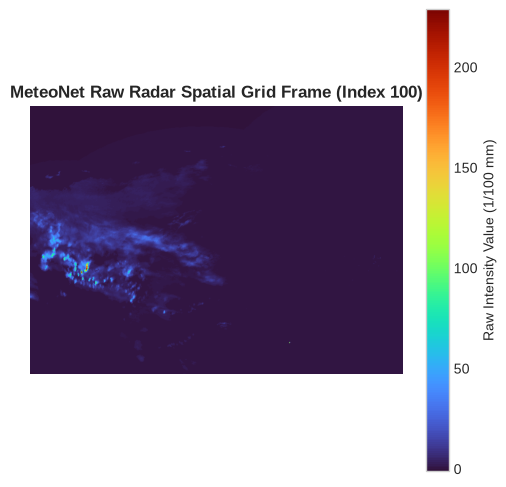

In [6]:
# Inspect an arbitrary single frame index
frame_idx = 100
frame = rainfall[frame_idx]

plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.colorbar(label="Raw Intensity Value (1/100 mm)")
plt.title(f"MeteoNet Raw Radar Spatial Grid Frame (Index {frame_idx})", weight="bold")
plt.axis("off")
plt.show()


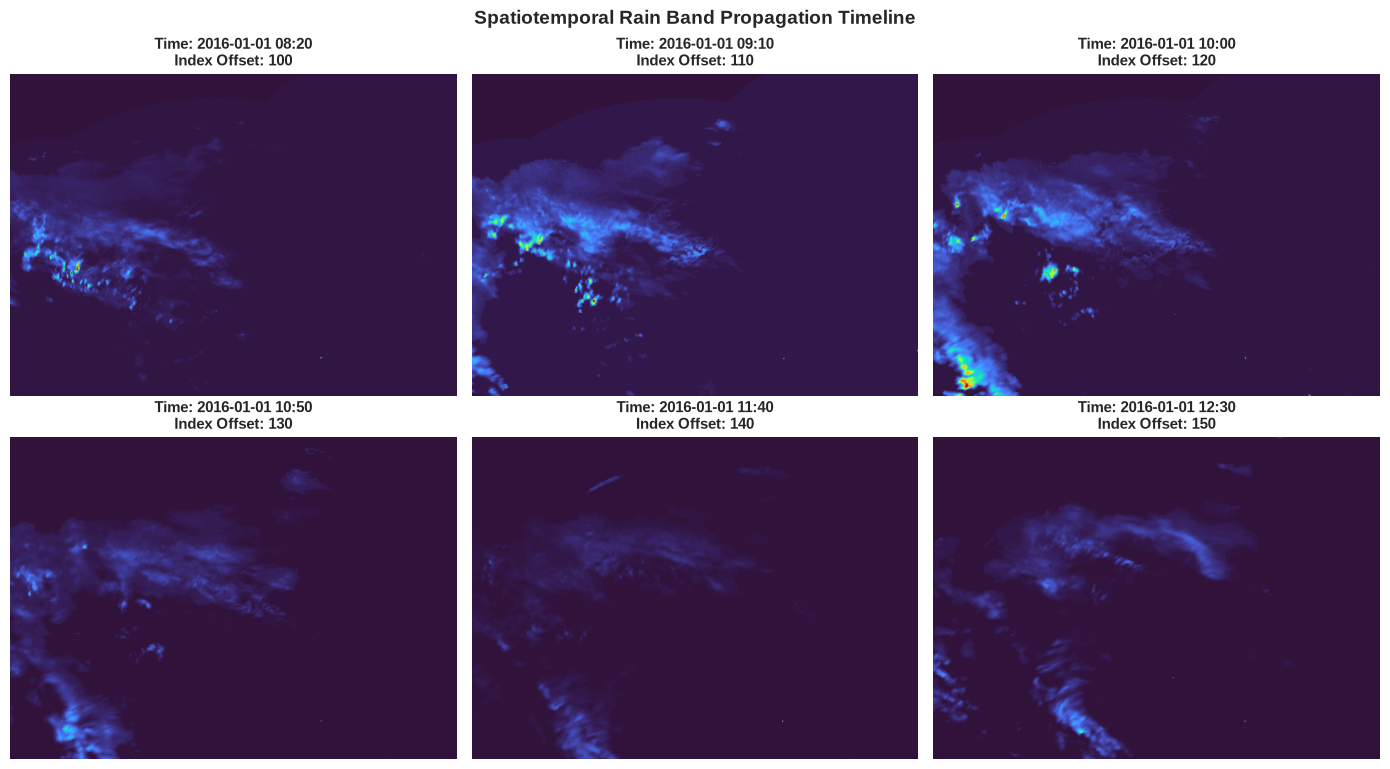

In [7]:
# Generate a chronological sequence timeline row matrix
fig, ax = plt.subplots(2, 3, figsize=(14, 8))
sample_indices = [100, 110, 120, 130, 140, 150]

for a, idx in zip(ax.ravel(), sample_indices):
    im = a.imshow(rainfall[idx])
    time_label = str(dates[idx]).replace('T', ' ')[:16]
    a.set_title(f"Time: {time_label}\nIndex Offset: {idx}", fontsize=11, weight="bold")
    a.axis("off")

plt.suptitle("Spatiotemporal Rain Band Propagation Timeline", fontsize=14, weight="bold", y=0.98)
plt.tight_layout()
plt.show()


> **Architectural Design Insight**: The stark visual sparsity confirmed above demonstrates that simple pixel-wise regression losses (like standard MSE) are easily dominated by zero-intensity background fields. This mathematical relationship risks causing models to over-optimize for dry states, leading to an under-prediction of severe storm events.


## 3. Heavy-Tailed Intensity Distributions & Transformation Profiles

Precipitation depths do not follow a standard Gaussian curve; they obey a strict **power-law distribution**. To design robust data clipping and scaling rules, pixel counts are analyzed across continuous percentile boundaries. 

To maintain memory efficiency and prevent out-of-memory spikes, statistics are generated using a strided, downsampled slice view of the array block instead of full array flattening.


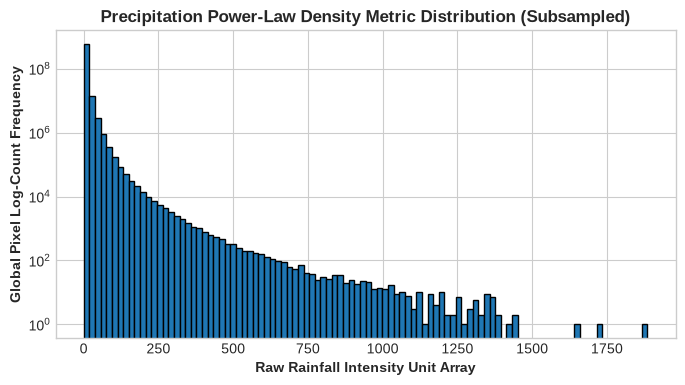

In [8]:
# Memory-efficient statistical profiling via strided slice views
subsampled_view = rainfall[::2, :, :]
clean_values = subsampled_view[subsampled_view >= 0]

plt.figure(figsize=(8, 4))
plt.hist(clean_values, bins=100, color="tab:blue", edgecolor="black", log=True)
plt.xlabel("Raw Rainfall Intensity Unit Array", weight="bold")
plt.ylabel("Global Pixel Log-Count Frequency", weight="bold")
plt.title("Precipitation Power-Law Density Metric Distribution (Subsampled)", weight="bold")
plt.show()


In [9]:
# Isolate active, non-zero rain values below a representative extreme band
filtered_values = clean_values[(clean_values > 0) & (clean_values < 100)]

# Calculate exact granular percentile cuts across the active rain field
p25, p50, p75, p95, p99 = np.percentile(filtered_values, [25, 50, 75, 95, 99])

print("Rain Intensity Percentile Boundaries (Filtered 0 < Value < 100):")
print("-" * 65)
print(f"25th Percentile          : {p25:.2f} (Trace)")
print(f"50th Percentile (Median) : {p50:.2f} (Light Rain)")
print(f"75th Percentile          : {p75:.2f} (Moderate)")
print(f"95th Percentile          : {p95:.2f} (Heavy Convective)")
print(f"99th Percentile          : {p99:.2f} (Extreme Downpour Core)")


Rain Intensity Percentile Boundaries (Filtered 0 < Value < 100):
-----------------------------------------------------------------
25th Percentile          : 3.00 (Trace)
50th Percentile (Median) : 7.00 (Light Rain)
75th Percentile          : 13.00 (Moderate)
95th Percentile          : 32.00 (Heavy Convective)
99th Percentile          : 58.00 (Extreme Downpour Core)


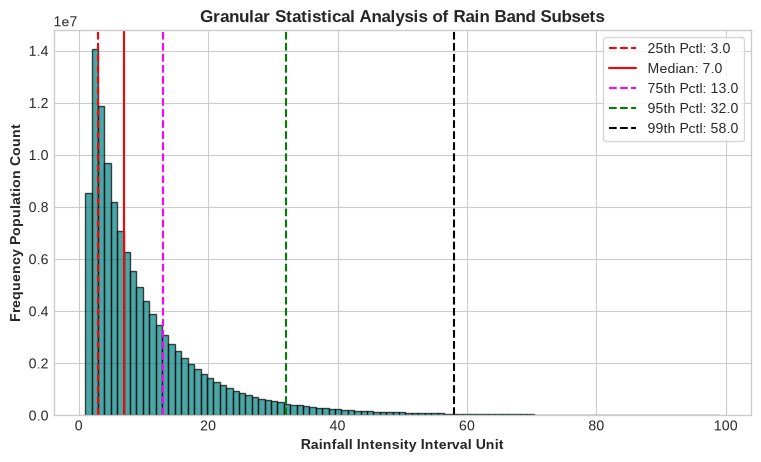

In [10]:
plt.figure(figsize=(9, 5))
plt.hist(filtered_values, bins=99, color="teal", alpha=0.7, edgecolor="black")
plt.xlabel("Rainfall Intensity Interval Unit", weight="bold")
plt.ylabel("Frequency Population Count", weight="bold")
plt.title("Granular Statistical Analysis of Rain Band Subsets", weight="bold")

# Superimpose exact vertical percentile thresholds
plt.axvline(p25, color="red", linestyle="--", linewidth=1.5, label=f"25th Pctl: {p25:.1f}")
plt.axvline(p50, color="red", linestyle="-", linewidth=1.5, label=f"Median: {p50:.1f}")
plt.axvline(p75, color="magenta", linestyle="--", linewidth=1.5, label=f"75th Pctl: {p75:.1f}")
plt.axvline(p95, color="green", linestyle="--", linewidth=1.5, label=f"95th Pctl: {p95:.1f}")
plt.axvline(p99, color="black", linestyle="--", linewidth=1.5, label=f"99th Pctl: {p99:.1f}")

plt.legend(fontsize=10, facecolor="white", frameon=True)
plt.show()


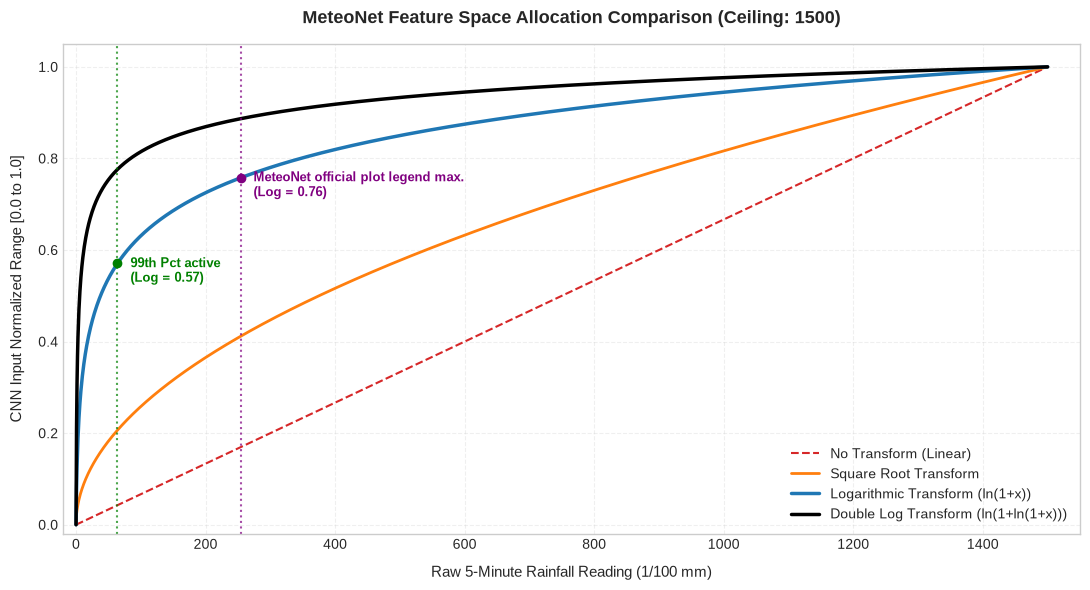

In [11]:
# --- COMPARATIVE TRANSFORMATION ANALYSIS ---
# Generate a smooth array of raw rainfall steps up to the 1500 cap
raw_x = np.linspace(0, 1500, 2000)

# Calculate the normalized curves [0.0, 1.0] for comparison
linear_y = raw_x / 1500.0
sqrt_y = np.sqrt(raw_x) / np.sqrt(1500.0)
log_y = np.log1p(raw_x) / np.log1p(1500.0)
double_log_y = np.log1p(np.log1p(raw_x)) / np.log1p(np.log1p(1500.0))

plt.figure(figsize=(11, 6), dpi=100)

# Plot the transformation curves
plt.plot(raw_x, linear_y, label="No Transform (Linear)", color="tab:red", linestyle="--", linewidth=1.5)
plt.plot(raw_x, sqrt_y, label="Square Root Transform", color="tab:orange", linewidth=2.0)
plt.plot(raw_x, log_y, label="Logarithmic Transform (ln(1+x))", color="tab:blue", linewidth=2.5)
plt.plot(raw_x, double_log_y, label="Double Log Transform (ln(1+ln(1+x)))", color="black", linewidth=2.5)

# Highlight critical thresholds with vertical marker lines
thresholds = {
    64: ("99th Pct active\n(Log = 0.57)", "green"),
    254: ("MeteoNet official plot legend max. \n(Log = 0.76)", "purple")
}

for val, (label, col) in thresholds.items():
    plt.axvline(x=val, color=col, linestyle=":", alpha=0.7, linewidth=1.5)
    log_val = np.log1p(val) / np.log1p(1500.0)
    plt.scatter(val, log_val, color=col, zorder=5)
    plt.text(val + 20, log_val - 0.04, label, fontsize=9, color=col, weight="bold")

plt.title("MeteoNet Feature Space Allocation Comparison (Ceiling: 1500)", fontsize=13, pad=15, weight="bold")
plt.xlabel("Raw 5-Minute Rainfall Reading (1/100 mm)", fontsize=11, labelpad=10)
plt.ylabel("CNN Input Normalized Range [0.0 to 1.0]", fontsize=11, labelpad=10)

plt.xlim(-20, 1550)
plt.ylim(-0.02, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(fontsize=10, loc="lower right")

plt.tight_layout()
plt.show()


> **Downstream Preprocessing Decision**: The long-tailed data structure shows that a minute fraction of extreme convective rain values can easily dominate linear scaling intervals. Based on the distribution curves plotted above, a **Logarithmic Transformation ($\log_{1p}$)** is chosen due to the highly tail-ended distribution of the radar data, where most values sit at or close to 0. 

> This transform achieves a much more uniform distribution without enforcing a super harsh cutoff (like capping everything at 100), ensuring that extreme weather events stay fully relevant and visible to the model. This protects backpropagation layers from gradient compression while handling convective storm cores cleanly up to a threshold ceiling of **1500**.


## 4. Sensor Gaps & Spatial Missing Value Diagnostics

According to the official Météo-France documentation, missing spatial radar sweeps are flagged by a distinct negative integer value of **-1**.

To protect the neural network layers from learning artificial signals, the overall volume, frequency, and probability footprints of missing data are evaluated.


In [12]:
missing_pixels_fraction = (rainfall == -1).mean(axis=(1, 2))

print(f"Average Missing Pixel Fraction per Frame : {missing_pixels_fraction.mean() * 100:.2f}%")
print(f"Maximum Missing Pixel Fraction observed  : {missing_pixels_fraction.max() * 100:.2f}%")
print(f"Minimum Missing Pixel Fraction observed  : {missing_pixels_fraction.min() * 100:.2f}%")


Average Missing Pixel Fraction per Frame : 7.80%
Maximum Missing Pixel Fraction observed  : 13.15%
Minimum Missing Pixel Fraction observed  : 7.49%


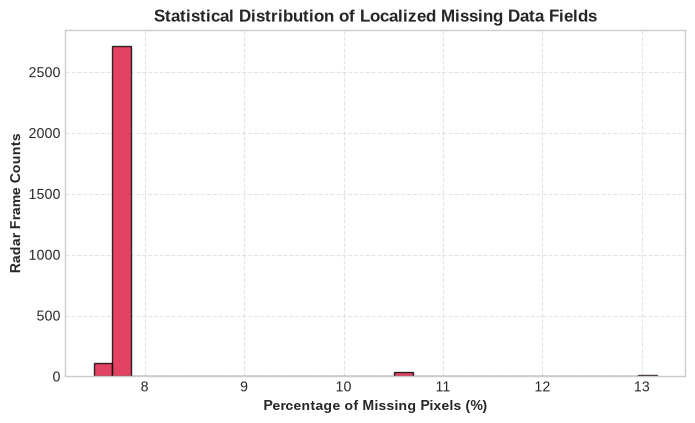

In [13]:
plt.figure(figsize=(8, 4.5))
plt.hist(missing_pixels_fraction * 100, bins=30, color="crimson", edgecolor="black", alpha=0.8)
plt.xlabel("Percentage of Missing Pixels (%)", weight="bold")
plt.ylabel("Radar Frame Counts", weight="bold")
plt.title("Statistical Distribution of Localized Missing Data Fields", weight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [14]:
target_sample_idx = 500
missing_pixels_mask = (rainfall[target_sample_idx] == -1)

# Isolate the original rain data and mask missing coordinates to zero for clean comparison
clean_rain_image = rainfall[target_sample_idx].copy()
clean_rain_image[clean_rain_image == -1] = 0


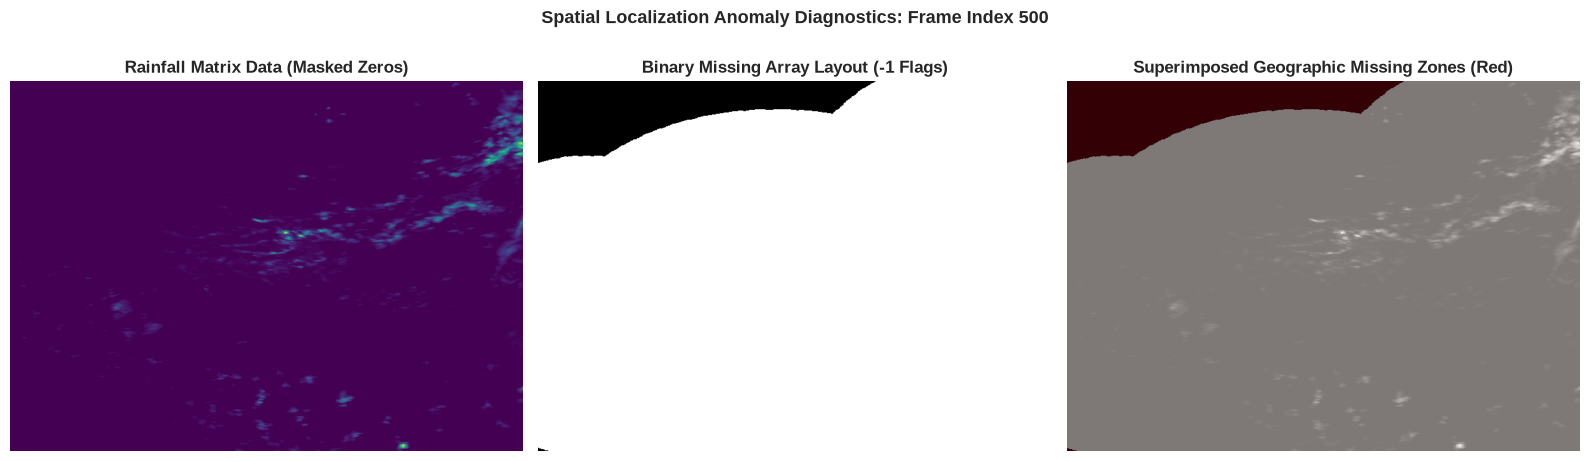

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(clean_rain_image, cmap="viridis")
ax[0].set_title("Rainfall Matrix Data (Masked Zeros)", weight="bold")

ax[1].imshow(missing_pixels_mask, cmap="gray_r")
ax[1].set_title("Binary Missing Array Layout (-1 Flags)", weight="bold")

ax[2].imshow(clean_rain_image, cmap="gray")
ax[2].imshow(np.where(rainfall[target_sample_idx] == -1, 1, 0), cmap="Reds", alpha=0.5)
ax[2].set_title("Superimposed Geographic Missing Zones (Red)", weight="bold")

for a in ax:
    a.axis("off")

plt.suptitle(f"Spatial Localization Anomaly Diagnostics: Frame Index {target_sample_idx}", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


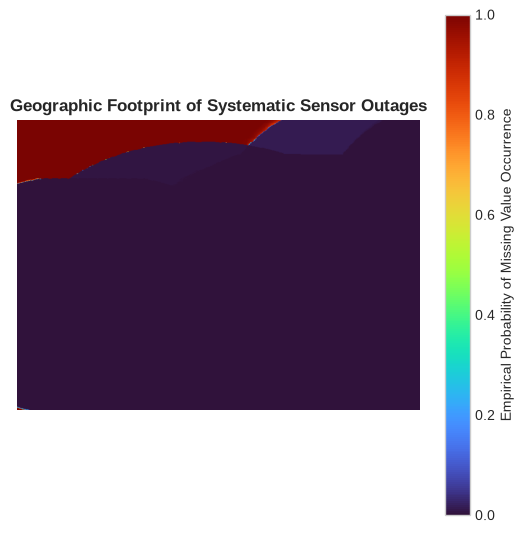

In [16]:
# Compute the long-term spatial probability footprint of missing values across the entire archive axis
missing_pixels_probability = (rainfall == -1).mean(axis=0)

plt.figure(figsize=(6.5, 6.5))
plt.imshow(missing_pixels_probability)
plt.colorbar(label="Empirical Probability of Missing Value Occurrence")
plt.title("Geographic Footprint of Systematic Sensor Outages", weight="bold")
plt.axis("off")
plt.show()


> **Preprocessing Decision**: The spatial probability footprint reveals that missing measurements are not random noise. Instead, they manifest as systematic, permanent geographic blocks caused by beam blockage or coastal radar physical boundaries. Replacing these -1 zones with static zero values would introduce severe label noise, leading the network to interpret sensor blind spots as true dry zones. 

> This observation highlights the need to extract a **dedicated parallel binary validity mask tensor (`target_masks`)** during preprocessing. Passing this mask to a custom `MaskedMSELoss` layer ensures invalid gradients are entirely skipped during optimization.


## 5. Temporal Continuity Validation

Time-series forecasting networks require an uninterrupted sequence of frames to learn atmospheric velocity vectors. Complete radar outages break temporal continuity and distort acceleration vectors.


In [17]:
expected_scans_count = len(dates) + len(miss_dates)

print(f"Total Available Sensor Scans : {len(dates)}")
print(f"Total Logged Missing Sweeps  : {len(miss_dates)}")
print(f"Nominal Expected Total Scans : {expected_scans_count}")
print(f"Empirical Data Availability  : {100 * len(dates) / expected_scans_count:.2f}%")


Total Available Sensor Scans : 2880
Total Logged Missing Sweeps  : 0
Nominal Expected Total Scans : 2880
Empirical Data Availability  : 100.00%


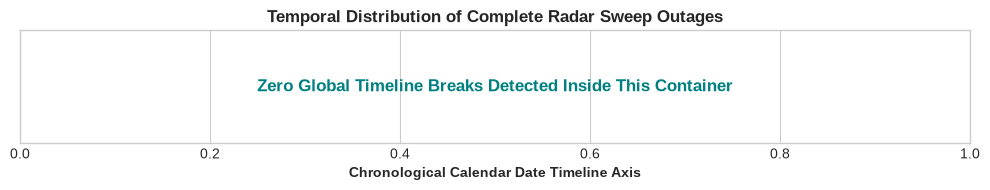

In [18]:
plt.figure(figsize=(10, 2))
if len(miss_dates) > 0:
    plt.scatter(miss_dates, np.ones(len(miss_dates)), s=15, color="red", marker="|", label="Timeline Interruption")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Zero Global Timeline Breaks Detected Inside This Container", 
             ha='center', va='center', fontsize=12, weight="bold", color="teal")
plt.yticks([])
plt.xlabel("Chronological Calendar Date Timeline Axis", weight="bold")
plt.title("Temporal Distribution of Complete Radar Sweep Outages", weight="bold")
plt.tight_layout()
plt.show()


> **Temporal Flow Diagnostic**: The current archive block exhibits zero missing scan breaks, indicating a contiguous timeline inside this container. However, strict checks must be maintained across adjacent blocks during sequence generation since missing scans degrade time-series stability.


In [19]:
# Compute individual step deltas between adjacent frames
time_deltas = np.diff(dates)
unique_intervals, population_counts = np.unique(time_deltas, return_counts=True)

print("Unique Time Deltas Detected Across Archive Sequence Rows:")
print("-" * 65)
for interval, count in zip(unique_intervals, population_counts):
    if hasattr(interval, "total_seconds"):
        minutes_val = int(interval.total_seconds() // 60)
    else:
        minutes_val = int(interval.astype("timedelta64[m]").astype(int))
        
    print(f"Delta: {str(interval):<15} ({minutes_val:>4} Minutes) | Population Count: {count}")


Unique Time Deltas Detected Across Archive Sequence Rows:
-----------------------------------------------------------------
Delta: 0:05:00         (   5 Minutes) | Population Count: 2879


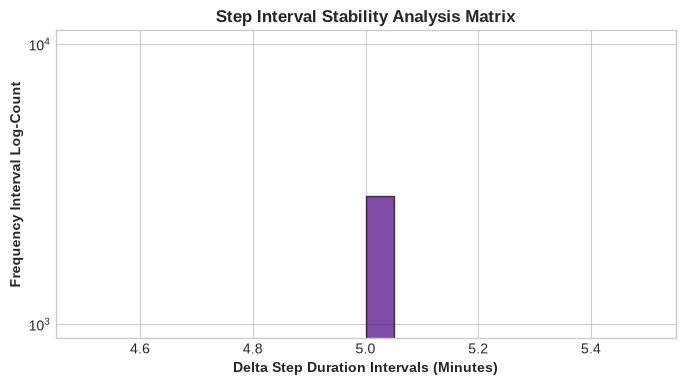

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(time_deltas.astype("timedelta64[m]").astype(int), bins=20, color="indigo", edgecolor="black", alpha=0.7)
plt.yscale("log")
plt.xlabel("Delta Step Duration Intervals (Minutes)", weight="bold")
plt.ylabel("Frequency Interval Log-Count", weight="bold")
plt.title("Step Interval Stability Analysis Matrix", weight="bold")
plt.show()


> **Temporal Continuity Constraint**: The expected sampling interval is strictly **5 minutes**. Any larger gap corresponds to missing radar scans and requires the sequence generator to discard the affected input-target forecast windows to protect the model from learning distorted motion dynamics.


## 6. Domain-Wide Spatial Average & Intensity Trends Over Time

Tracking the domain mean and domain maximum intensities across the entire chronological archive axis reveals macro-scale storm cycles (birth, peak intensity, and decay). This allows verification of the consistency of data partitioning choices.


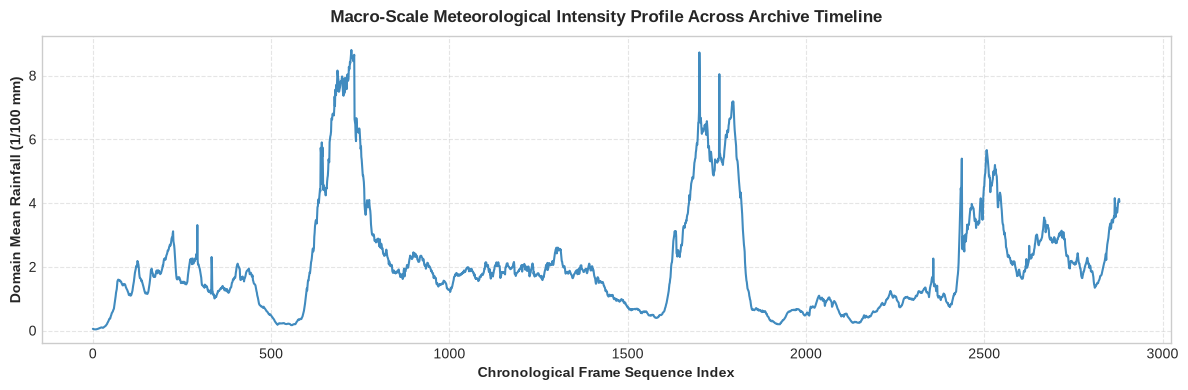

In [21]:
# Isolate a clean view mapping to zero for structural trend visibility 
clean_rainfall_tensor = rainfall.copy()
clean_rainfall_tensor[clean_rainfall_tensor == -1] = 0

mean_rain_series = clean_rainfall_tensor.mean(axis=(1, 2))

plt.figure(figsize=(12, 4))
plt.plot(mean_rain_series, color="tab:blue", linewidth=1.5, alpha=0.85)
plt.xlabel("Chronological Frame Sequence Index", weight="bold")
plt.ylabel("Domain Mean Rainfall (1/100 mm)", weight="bold")
plt.title("Macro-Scale Meteorological Intensity Profile Across Archive Timeline", weight="bold", pad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


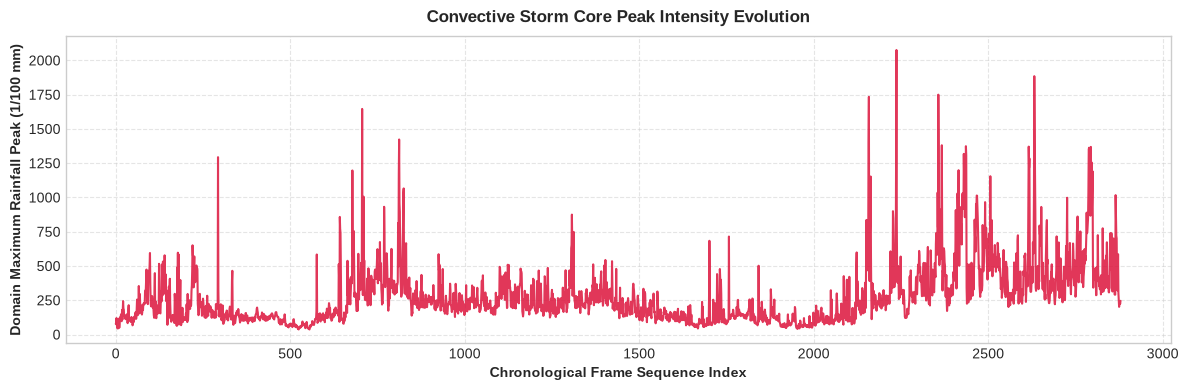

In [22]:
# Track peak convective intensities per frame across the archive axis
max_rain_series = clean_rainfall_tensor.max(axis=(1, 2))

plt.figure(figsize=(12, 4))
plt.plot(max_rain_series, color="crimson", linewidth=1.5, alpha=0.85)
plt.xlabel("Chronological Frame Sequence Index", weight="bold")
plt.ylabel("Domain Maximum Rainfall Peak (1/100 mm)", weight="bold")
plt.title("Convective Storm Core Peak Intensity Evolution", weight="bold", pad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Executive Summary & Preprocessing Action Plan

This exploratory data analysis highlights five critical data characteristics that shape the end-to-end nowcasting software architecture. To build a robust pipeline that aligns with industrial standards, these raw observations are translated into concrete steps within the preprocessing pipeline:

### Summary of Core Empirical Observations:
* **5-Minute Sampling Interval**: Nominal radar scans occur exactly every 5 minutes. Any temporal interval delta larger than 5 minutes signifies an operational scan outage.
* **Temporal Discontinuities**: Missing radar scans occasionally interrupt chronological sequence rows. Because predictive spatiotemporal models require continuous history tracking, any time gap will distort acceleration vectors.
* **Systematic Spatial Outages**: Invalid spatial measurements are explicitly encoded via native -1 flag matrices. These are not random pixel noise; they map to fixed geographic boundaries (terrain blockages).
* **Extreme Power-Law Skew**: The distribution of rainfall is heavily skewed toward zero, but features a minute fraction of extreme convective rain values that create long-tailed behavior.
* **High Spatial Dimensions**: The original radar images are sufficiently large that training directly on them introduces heavy computational and GPU VRAM scaling overhead.

### Strategic Preprocessing Blueprint:
1. **Geometric Interpolation**: Downsample spatial dimensions using area-averaging logic (`cv2.INTER_AREA`) for continuous arrays to optimize deep learning training runtimes, while maintaining binary validity mask structures via nearest-neighbor mapping (`cv2.INTER_NEAREST`).
2. **Extreme Outlier Slicing**: Enforce a hard threshold ceiling at **1500** *before* downsampling to suppress extreme, anomalous convective spikes, preventing localized anomalies from bleeding into surrounding grids during interpolation.
3. **Logarithmic Scaling Transformation**: Linearize raw precipitation inputs using a global $\log_{1p}$ scale normalized against the maximum clipped range. This spreads out active radar reflections across the standard floating-point interval, preventing gradient compression during optimization while preserving extreme weather representation.
4. **Parallel Validity Mask Extraction**: Map spatial -1 flag grids into parallel binary validity masks to isolate clean coordinates, ensuring sensor gaps do not introduce label noise during backpropagation.
5. **Strict Temporal Sequence Filtering**: Configure the sequence generator to strictly discard any input-target loop sequence containing an internal delta step gap larger than 5 minutes, guaranteeing clean temporal data continuity.
